In [156]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import geopandas as gpd
import pandas as pd
import os

from shapely.geometry import box
import numpy as np

import rasterio
from rasterio.mask import mask
from rasterio.features import geometry_mask

In [149]:
def extract_population(shape, raster):
    geom = [shape]
    out_image, out_transform = mask(raster, geom, crop=True)
    nodata_value = raster.nodata
    out_image = np.where(out_image == nodata_value, 0, out_image)    
    return out_image.sum()

In [157]:
ghana = gpd.read_file("./gh_shp/gh.shp")
raster_path = "./ghana_population.tif"
raster = rasterio.open(raster_path)

In [160]:
# Define the bounding box of Ghana
minx, miny, maxx, maxy = ghana.total_bounds

# Grid cell size (in degrees or meters depending on the CRS)
cell_size = 0.05
grid_cells = []
for x in np.arange(minx, maxx, cell_size):
    for y in np.arange(miny, maxy, cell_size):
        grid_cells.append(box(x, y, x+cell_size, y+cell_size))

grid = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=ghana.crs)
grid_within_ghana = gpd.overlay(grid, ghana, how='intersection')

In [161]:
ghana['Population'] = ghana['geometry'].apply(lambda x: extract_population(x, raster))
grid_within_ghana['Population'] = grid_within_ghana['geometry'].apply(lambda x: extract_population(x, raster))

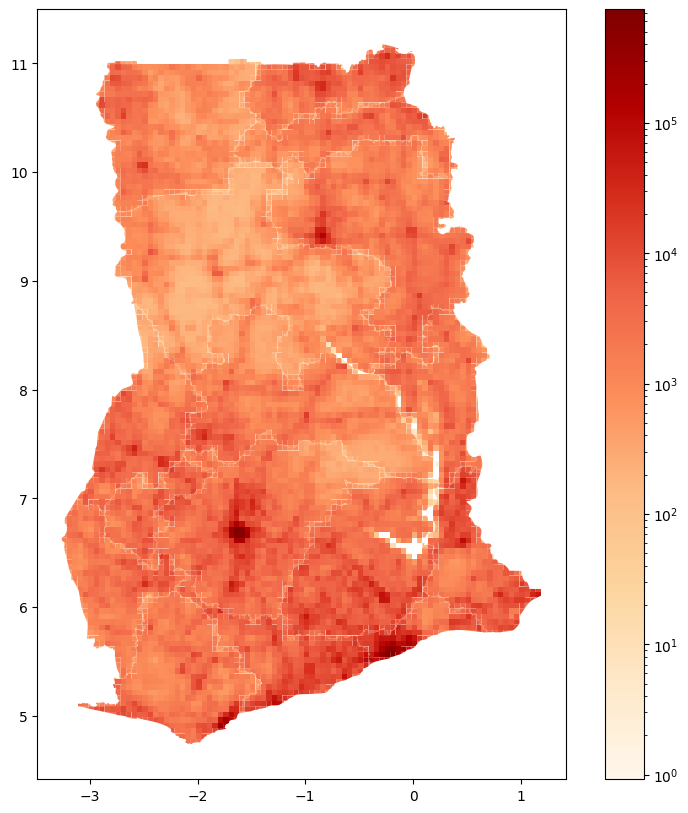

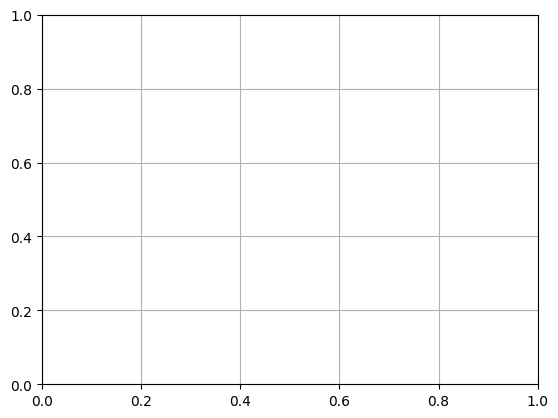

In [164]:
grid_within_ghana.plot(column='Population', cmap='OrRd', legend=True, figsize=(10, 10), norm=LogNorm())
plt.show()